# Question 4 — Problem 1 with Modified Gradient Descent

**Original update rule:** $t = t - \alpha \frac{d}{dt}J(t)$ → moves **down** the slope (minimisation)

**Modified update rule:** $t = t + \alpha \frac{d}{dt}J(t)$ → moves **up** the slope (maximisation)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cost function and its derivative (same as Problem 1)
def g(t):
    return t**4 - 4*t**2 + 5

def dg(t):
    return 4*t**3 - 8*t

t_1 = np.linspace(-2, 2, 1000)

---
## Part (a) — Original vs Modified Gradient Descent

The **only change** is `+` instead of `-` in the update rule.

In [3]:
# ── ORIGINAL gradient descent: t = t - α·dg(t) ──────────────────────
def gradient_descent_original(dg, initial_value, learning_rate, precision, max_iter):
    t = initial_value
    t_list = []
    for i in range(1, max_iter + 1):
        t_list.append(t)
        t = t - learning_rate * dg(t)      # MINUS → go downhill
        if abs(learning_rate * dg(t)) <= precision:
            break
    return t, t_list, i

# ── MODIFIED gradient descent: t = t + α·dg(t) ───────────────────────
def gradient_descent_modified(dg, initial_value, learning_rate, precision, max_iter):
    t = initial_value
    t_list = []
    for i in range(1, max_iter + 1):
        t_list.append(t)
        t = t + learning_rate * dg(t)      # PLUS → go uphill
        if abs(learning_rate * dg(t)) <= precision:
            break
    return t, t_list, i

# ── Run both ──────────────────────────────────────────────────────────
params = dict(initial_value=0.5, learning_rate=0.02,
              precision=0.0001, max_iter=1000)

t_orig,  t_list_orig,  runs_orig  = gradient_descent_original(dg, **params)
t_mod,   t_list_mod,   runs_mod   = gradient_descent_modified(dg, **params)

print('=' * 52)
print('  ORIGINAL  (t = t - α·dg(t))')
print('=' * 52)
print(f'  Result t            : {t_orig:.6f}')
print(f'  Cost g(t)           : {g(t_orig):.6f}')
print(f'  Slope dg(t)         : {dg(t_orig):.6f}')
print(f'  Iterations          : {runs_orig}')
print(f'  Finds               : LOCAL MINIMUM')
print()
print('=' * 52)
print('  MODIFIED  (t = t + α·dg(t))')
print('=' * 52)
print(f'  Result t            : {t_mod:.6f}')
print(f'  Cost g(t)           : {g(t_mod):.6f}')
print(f'  Slope dg(t)         : {dg(t_mod):.6f}')
print(f'  Iterations          : {runs_mod}')
print(f'  Finds               : LOCAL MAXIMUM (saddle point at t≈0)')

  ORIGINAL  (t = t - α·dg(t))
  Result t            : 1.413925
  Cost g(t)           : 1.000001
  Slope dg(t)         : -0.004608
  Iterations          : 27
  Finds               : LOCAL MINIMUM

  MODIFIED  (t = t + α·dg(t))
  Result t            : 0.000607
  Cost g(t)           : 4.999999
  Slope dg(t)         : -0.004857
  Iterations          : 39
  Finds               : LOCAL MAXIMUM (saddle point at t≈0)


---
## Part (b) — Plot: function + search traces

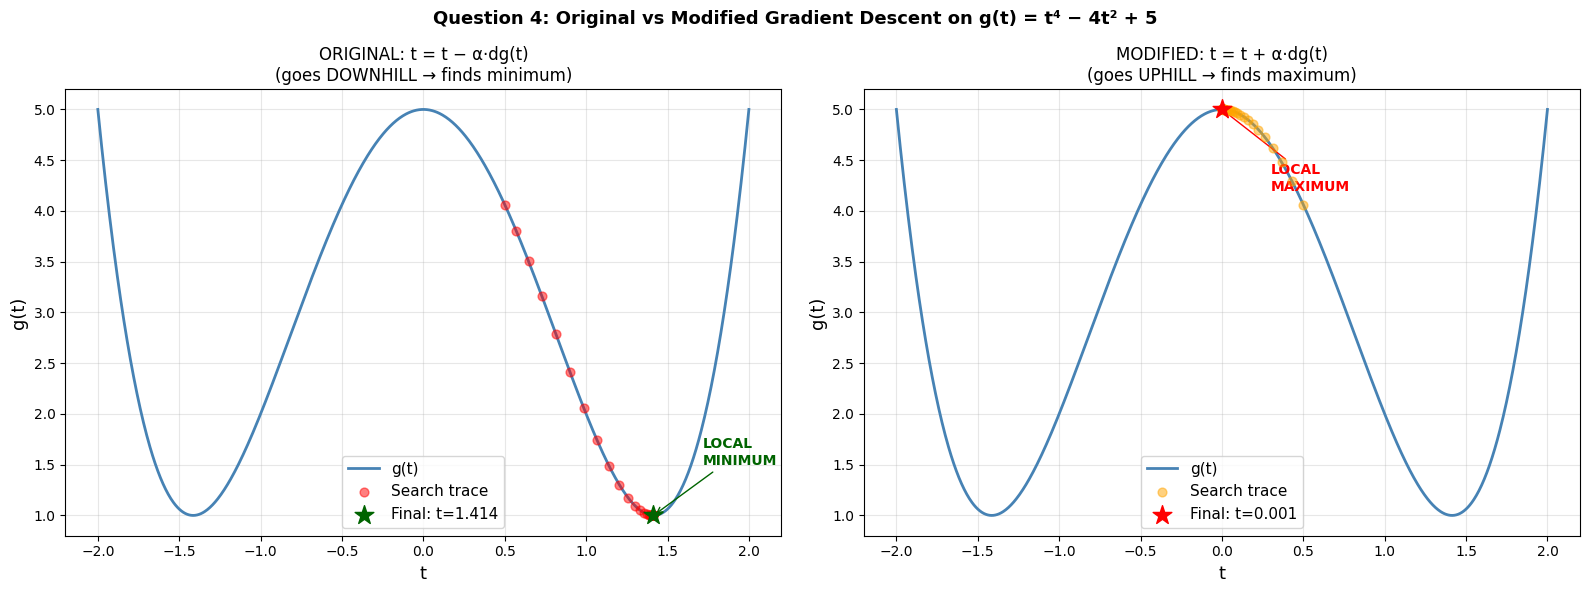

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left plot: Original (minus) ───────────────────────────────────────
ax1 = axes[0]
ax1.plot(t_1, g(t_1), color='steelblue', linewidth=2, label='g(t)')
ax1.scatter(t_list_orig, g(np.array(t_list_orig)),
            color='red', alpha=0.5, s=40, zorder=5, label='Search trace')
ax1.scatter([t_orig], [g(t_orig)],
            color='darkgreen', s=200, zorder=6, marker='*', label=f'Final: t={t_orig:.3f}')
ax1.set_xlabel('t', fontsize=13)
ax1.set_ylabel('g(t)', fontsize=13)
ax1.set_title('ORIGINAL: t = t − α·dg(t)\n(goes DOWNHILL → finds minimum)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.annotate('LOCAL\nMINIMUM', xy=(t_orig, g(t_orig)),
             xytext=(t_orig+0.3, g(t_orig)+0.5),
             arrowprops=dict(arrowstyle='->', color='darkgreen'),
             fontsize=10, color='darkgreen', fontweight='bold')

# ── Right plot: Modified (plus) ───────────────────────────────────────
ax2 = axes[1]
ax2.plot(t_1, g(t_1), color='steelblue', linewidth=2, label='g(t)')
ax2.scatter(t_list_mod, g(np.array(t_list_mod)),
            color='orange', alpha=0.5, s=40, zorder=5, label='Search trace')
ax2.scatter([t_mod], [g(t_mod)],
            color='red', s=200, zorder=6, marker='*', label=f'Final: t={t_mod:.3f}')
ax2.set_xlabel('t', fontsize=13)
ax2.set_ylabel('g(t)', fontsize=13)
ax2.set_title('MODIFIED: t = t + α·dg(t)\n(goes UPHILL → finds maximum)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.annotate('LOCAL\nMAXIMUM', xy=(t_mod, g(t_mod)),
             xytext=(t_mod+0.3, g(t_mod)-0.8),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red', fontweight='bold')

plt.suptitle('Question 4: Original vs Modified Gradient Descent on g(t) = t⁴ − 4t² + 5',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part (c) — What difference do you observe?

| | Original `t = t − α·dg(t)` | Modified `t = t + α·dg(t)` |
|---|---|---|
| Direction of movement | **Downhill** (against gradient) | **Uphill** (with gradient) |
| What it finds | **Local minimum** | **Local maximum / saddle point** |
| Final `t` | ≈ 1.414 | ≈ 0.0 |
| Final cost `g(t)` | ≈ **1.0** (lowest point) | ≈ **5.0** (highest local point) |
| Name | **Gradient Descent** | **Gradient Ascent** |

### Why does this happen?

The derivative $\frac{d}{dt}g(t)$ tells us the **slope direction**:

- **Subtracting** it (`−`) moves us **opposite** to the slope → downhill → **minimum** ✅
- **Adding** it (`+`) moves us **along** the slope → uphill → **maximum** ❌ (for minimisation)

### Visual Summary
```
Starting at t = 0.5 (on right side of local max at t=0)

Original (−):  0.5 → 0.6 → ... → 1.414  (rolls DOWN to minimum)
Modified (+):  0.5 → 0.43 → ... → 0.0   (rolls UP to local maximum)
```

> **Conclusion:** Changing minus to plus converts **Gradient Descent (minimisation)** into **Gradient Ascent (maximisation)**. In machine learning we always use **minus** because we want to **minimise** the cost/loss function.